# Lab 3: Introduction to Quantum Error Correction in stim

**[EQE5006] Quantum Error Correction, Spring 2026**

In this lab, you will implement the quantum error-correcting codes from Lecture 04 using stim. Starting with the three-qubit bit flip code, you will build the complete QEC workflow — encoding, noise, ancilla-based syndrome extraction, and classical recovery — and estimate logical error rates via Monte Carlo simulation. You will then extend this to the phase flip code, verify the Shor code, and preview stim's detector framework.

**Prerequisites**: Lab 1-2, Lecture 04 (Introduction to Quantum Error Correction)

In [ ]:
# Install stim if not already installed
!pip install stim -q

In [ ]:
import stim
import numpy as np
import matplotlib.pyplot as plt

print(f"stim version: {stim.__version__}")

---

## Section 1: The Three-Qubit Bit Flip Code

In Lecture 04, we learned the simplest quantum error-correcting code: the three-qubit bit flip code. It encodes one logical qubit into three physical qubits:

$$|0\rangle \to |0_L\rangle = |000\rangle, \quad |1\rangle \to |1_L\rangle = |111\rangle$$

The QEC workflow has four steps:

$$\boxed{\text{Encode}} \longrightarrow \boxed{\text{Noise}} \longrightarrow \boxed{\text{Syndrome}} \longrightarrow \boxed{\text{Recover}}$$

Let's build each step in stim.

### The encoding circuit

The encoding uses two CNOT gates from the data qubit (q0) to two ancilla qubits (q1, q2), initialized in $|0\rangle$:

$$|0\rangle|00\rangle \xrightarrow{\text{CNOT}_{01}} |0\rangle|00\rangle \xrightarrow{\text{CNOT}_{02}} |000\rangle = |0_L\rangle$$

$$|1\rangle|00\rangle \xrightarrow{\text{CNOT}_{01}} |1\rangle|10\rangle \xrightarrow{\text{CNOT}_{02}} |111\rangle = |1_L\rangle$$

By linearity: $\alpha|0\rangle + \beta|1\rangle \to \alpha|000\rangle + \beta|111\rangle$. This is **not** cloning — the three qubits are entangled, not independent copies.

In [61]:
def make_bit_flip_encoding():
    """Return a circuit that encodes q0 into the 3-qubit bit flip code."""
    circuit = stim.Circuit()
    circuit.append("R", [1, 2])
    circuit.append("CNOT", [0, 1])
    circuit.append("CNOT", [0, 2])
    return circuit

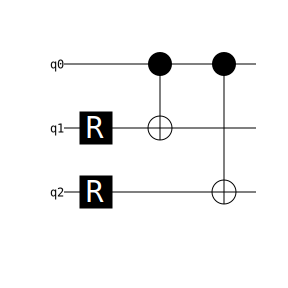

In [62]:
# |0_L>: input |000> stays |000>
c0 = make_bit_flip_encoding()
c0.diagram("timeline-svg")

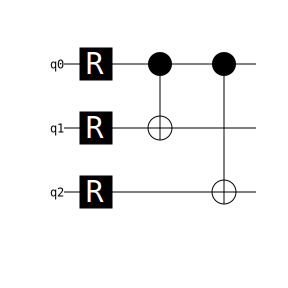

In [63]:
# |0> -> |000>

c0 = stim.Circuit()
c0.append("R", [0])
c0 += make_bit_flip_encoding()
c0.diagram("timeline-svg")

In [64]:
c0.append("M", [0, 1, 2])
c0.compile_sampler().sample(shots=10)

array([[False, False, False],
       [False, False, False],
       [False, False, False],
       [False, False, False],
       [False, False, False],
       [False, False, False],
       [False, False, False],
       [False, False, False],
       [False, False, False],
       [False, False, False]])

In [ ]:
# |1> -> |111>
c1 = stim.Circuit()
c1.append("R", [0])
c1.append("X", [0])
c1 += make_bit_flip_encoding()
c1.diagram("timeline-svg")

In [ ]:
c1.append("M", [0, 1, 2])
s1 = c1.compile_sampler().sample(shots=10)

In [ ]:
# Encode |+> -> (|000> + |111>)/sqrt(2): the GHZ state
c_ghz = stim.Circuit()
c_ghz.append("RX", [0])
c_ghz += make_bit_flip_encoding()

c_ghz.diagram("timeline-svg")

In [ ]:
c_ghz.append("M", [0, 1, 2])

samples = c_ghz.compile_sampler().sample(shots=100)
samples

In [ ]:
# Check if all three measurements in each shot are equal
all_equal = (samples[:, 0] == samples[:, 1]) & (samples[:, 1] == samples[:, 2])
all_equal

### Syndrome extraction with ancilla qubits

From Lecture 04, the syndrome operators for the bit flip code are $Z_0Z_1$ and $Z_1Z_2$. To measure these without disturbing the encoded state, we use **ancilla qubits**.

To measure the parity $Z_iZ_j$ (whether qubits $i$ and $j$ agree), we introduce an ancilla qubit initialized to $|0\rangle$ and apply CNOT from each data qubit to the ancilla:

- CNOT $q_i \to$ ancilla, then CNOT $q_j \to$ ancilla
- The ancilla now holds $q_i \oplus q_j$ (the parity)
- Measure the ancilla: result 0 means $Z_iZ_j = +1$ (agree), result 1 means $Z_iZ_j = -1$ (differ)

We use two ancilla qubits (q3 for $Z_0Z_1$, q4 for $Z_1Z_2$) to extract both syndrome bits simultaneously.

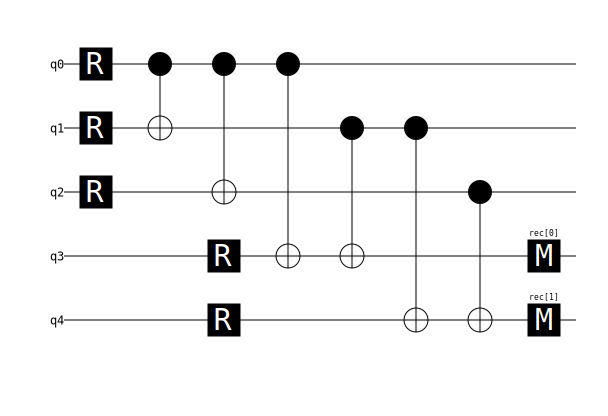

In [67]:
def make_bit_flip_syndrome():
    """Measure Z_0Z_1 (into q3) and Z_1Z_2 (into q4) for the bit flip code."""
    circuit = stim.Circuit()
    # Prepare ancillas in |0>
    circuit.append("R", [3, 4])
    # Z_0Z_1: parity of q0, q1 -> ancilla q3
    circuit.append("CNOT", [0, 3])
    circuit.append("CNOT", [1, 3])
    # Z_1Z_2: parity of q1, q2 -> ancilla q4
    circuit.append("CNOT", [1, 4])
    circuit.append("CNOT", [2, 4])
    # Measure ancillas
    circuit.append("M", [3, 4])
    return circuit


# No error: syndrome should always be (0, 0)
c = stim.Circuit()
c.append("R", [0])
c += make_bit_flip_encoding()
c += make_bit_flip_syndrome()
c.diagram("timeline-svg")

In [68]:
samples = c.compile_sampler().sample(shots=10)
samples

array([[False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False]])

In [70]:
# Inject a deterministic X error on each qubit and check the syndrome
for error_qubit in [0, 1, 2]:
    c = stim.Circuit()
    c.append("R", [0])
    c += make_bit_flip_encoding()
    c.append("X", [error_qubit])
    c += make_bit_flip_syndrome()
    samples = c.compile_sampler().sample(shots=1)
    s1, s2 = int(samples[0, 0]), int(samples[0, 1])
    print(f"X error on q{error_qubit}: syndrome = ({s1}, {s2})")
    print()

X error on q0: syndrome = (1, 0)

X error on q1: syndrome = (1, 1)

X error on q2: syndrome = (0, 1)



This matches the syndrome table from Lecture 04:

| Syndrome $(s_1, s_2)$ | Diagnosis | Recovery |
|:---:|:---|:---|
| (0, 0) | No error | Do nothing |
| (1, 0) | Bit flip on q0 | Apply $X_0$ |
| (1, 1) | Bit flip on q1 | Apply $X_1$ |
| (0, 1) | Bit flip on q2 | Apply $X_2$ |

### The complete QEC cycle

Now let's put it all together. We build a single circuit that performs **encoding, noise, syndrome extraction, and data measurement**. The recovery step is done in classical post-processing: we read the syndrome, determine which qubit to correct, and flip the corresponding measurement result.

The measurement order is: $[s_1, s_2, d_0, d_1, d_2]$.

In [ ]:
def make_bit_flip_qec_circuit(p):
    """Build the complete bit flip code QEC circuit.

    Parameters
    ----------
    p : float
        Physical bit flip error probability per qubit.

    Returns
    -------
    stim.Circuit
        Measurement order: [s1, s2, d0, d1, d2].
    """
    circuit = stim.Circuit()
    circuit.append("R", [0])
    circuit += make_bit_flip_encoding()
    circuit.append("X_ERROR", [0, 1, 2], p)
    circuit += make_bit_flip_syndrome()
    circuit.append("M", [0, 1, 2])
    return circuit


c = make_bit_flip_qec_circuit(0.01)
c.diagram("timeline-svg")

In [ ]:
# seed = 42
seed = 0

circuit = make_bit_flip_qec_circuit(0.2)
samples = circuit.compile_sampler(seed=seed).sample(shots=1)
s1, s2 = samples[0, 0], samples[0, 1]
d0, d1, d2 = samples[0, 2], samples[0, 3], samples[0, 4]

print(f"Syndrome: {s1}, {s2}")
print(f"Data qubit measurements: {d0}, {d1}, {d2}")

In [ ]:
# Apply correction based on syndrome
corrected_d0 = d0 ^ (s1 & ~s2)  # syndrome (1,0) -> flip q0
corrected_d1 = d1 ^ (s1 & s2)  # syndrome (1,1) -> flip q1
corrected_d2 = d2 ^ (~s1 & s2)  # syndrome (0,1) -> flip q2

print(
    f"Corrected data qubit measurements: {corrected_d0}, {corrected_d1}, {corrected_d2}"
)

In [ ]:
# Obtain logical Z observable outcome after correction
logical_Z_outcome = corrected_d0
decoding_success = logical_Z_outcome == False

print(f"Decoding successful? {decoding_success}")

In [ ]:
def decode_bit_flip(samples):
    """Decode bit flip code: apply correction and check for logical error.

    Parameters
    ----------
    samples : np.ndarray
        Shape (shots, 5) with columns [s1, s2, d0, d1, d2].

    Returns
    -------
    np.ndarray
        Boolean array of shape (shots,) -- True where a logical error occurred.
    """
    s1, s2 = samples[:, 0], samples[:, 1]
    d0, d1, d2 = samples[:, 2], samples[:, 3], samples[:, 4]

    # Apply correction based on syndrome
    corrected_d0 = d0 ^ (s1 & ~s2)  # syndrome (1,0) -> flip q0
    corrected_d1 = d1 ^ (s1 & s2)  # syndrome (1,1) -> flip q1
    corrected_d2 = d2 ^ (~s1 & s2)  # syndrome (0,1) -> flip q2
    # Logical Z_L = Z_0: error if q0 is 1 after correction (encoded |0_L>)
    return corrected_d0.astype(bool)


# Demo at p = 0.1
p = 0.1
shots = 10000
circuit = make_bit_flip_qec_circuit(p)
samples = circuit.compile_sampler().sample(shots=shots)
logical_errors = decode_bit_flip(samples)

p_logical = np.mean(logical_errors)
p_theory = 3 * p**2 - 2 * p**3
print(f"Physical error rate:  p = {p}")
print(f"Logical error rate:   p_L = {p_logical:.4f}")
print(f"Theoretical:          3p^2 - 2p^3 = {p_theory:.4f}")

### Exercise 1.1 — Logical vs. physical error rate plot

Plot the logical error rate $p_L$ as a function of the physical error rate $p$ for $p \in [0, 0.5]$. Include:
- Monte Carlo estimates (data points with markers)
- Theoretical curve $p_L = 3p^2 - 2p^3$ (solid line)
- Break-even line $p_L = p$ (dashed line)

**Question**: Find the break-even point $p^*$ where $p_L = p$ analytically. *Hint*: solve $3p^2 - 2p^3 = p$.

In [ ]:
# Exercise 1.2

p_values = np.linspace(0.001, 0.5, 20)
shots = 10000
logical_error_rates = []

pLs = []
for p in p_values:
    # Your code here
    pass

# --- Plotting template ---
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(p_values, pLs, "o", label="Monte Carlo")
ax.plot(p_values, 3 * p_values**2 - 2 * p_values**3, label="Theoretical")
ax.plot(p_values, p_values, "--", label="Break-even")
ax.set_xlabel("Physical error rate $p$")
ax.set_ylabel("Logical error rate $p_L$")
ax.set_title("Bit flip code: logical vs. physical error rate")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Exercise 1.2 — The bit flip code cannot correct phase errors

The bit flip code protects against $X$ errors, but what about $Z$ (phase flip) errors? Since the syndrome operators $Z_0Z_1$ and $Z_1Z_2$ **commute** with any $Z$ error ($[Z_iZ_j,\, Z_k] = 0$), the syndrome is always $(0, 0)$ regardless of which qubit is affected. The code is completely blind to phase flips.

In [ ]:
# Demonstrate: Z errors are invisible to the bit flip code syndrome
# Use X-basis initialization (|+_L>) and X_L measurement to reveal the damage


def make_bit_flip_qec_circuit_with_z_error(error_qubit, error_probability):
    """Create a bit flip code circuit with a Z error on the specified qubit."""
    c = stim.Circuit()
    # TODO: Encode |+> with the 3-qubit bit flip code (X_L initialization)
    # TODO: Apply Z error on the specified qubit
    # TODO: Measure syndrome with ancillary qubits
    c.append("MX", [0, 1, 2])  # X_L measurement

    return c


c = make_bit_flip_qec_circuit_with_z_error(1, 0.1)
c.diagram("timeline-svg")

In [ ]:
samples = c.compile_sampler().sample(shots=100)
samples[:, 0]

In [ ]:
# Monte Carlo: logical error rate with Z_ERROR
print()
print("Logical error rate with Z_ERROR (X-basis init & measurement):")
for p in [0.05, 0.1, 0.2]:
    circuit = make_bit_flip_qec_circuit_with_z_error(0, p)
    samples = circuit.compile_sampler().sample(shots=10000)
    logical_X_outcome = samples[:, 2] ^ samples[:, 3] ^ samples[:, 4]
    p_logical = np.mean(logical_X_outcome)
    p_theory = 3 * p * (1 - p) ** 2 + p**3
    print(
        f"  p = {p}: p_L = {p_logical:.4f}  (theory: {p_theory:.4f}, uncoded: {p:.4f})"
    )

By initializing in the $X$ basis ($|{+}_L\rangle$) and measuring $X_L = X_0X_1X_2$, the $Z$ error damage becomes directly visible:

- The syndrome is always $(0, 0)$ — the code cannot detect $Z$ errors at all
- Yet the logical error rate is $p_L \approx 3p$ for small $p$, **three times worse** than an uncoded qubit

The bit flip code's redundancy, which helps against $X$ errors, actually *amplifies* $Z$ errors: each of the three physical qubits is independently vulnerable to phase flips. Correcting phase errors requires the **phase flip code** in Section 2.

---

## Section 2: The Three-Qubit Phase Flip Code

The phase flip code is obtained from the bit flip code by applying $H^{\otimes 3}$. This Hadamard conjugation transforms everything:

| | Bit flip code | Phase flip code |
|:---|:---:|:---:|
| Protects against | $X$ errors | $Z$ errors |
| Codewords | $\vert000\rangle, \vert111\rangle$ | $\vert{+}{+}{+}\rangle, \vert{-}{-}{-}\rangle$ |
| Syndrome operators | $Z_0Z_1, Z_1Z_2$ | $X_0X_1, X_1X_2$ |
| Recovery | Apply $X_i$ | Apply $Z_i$ |

The encoding circuit is the bit flip encoding followed by $H$ on all three data qubits.

### Phase flip encoding

Encoding $|0\rangle \to |0_L\rangle = |{+}{+}{+}\rangle$ and $|1\rangle \to |1_L\rangle = |{-}{-}{-}\rangle$:

1. Apply the bit flip encoding: $\alpha|0\rangle + \beta|1\rangle \to \alpha|000\rangle + \beta|111\rangle$
2. Apply $H$ to each data qubit: $\alpha|000\rangle + \beta|111\rangle \to \alpha|{+}{+}{+}\rangle + \beta|{-}{-}{-}\rangle$

To verify the encoding, we measure in the **$X$ basis** (apply $H$ then measure in the $Z$ basis).

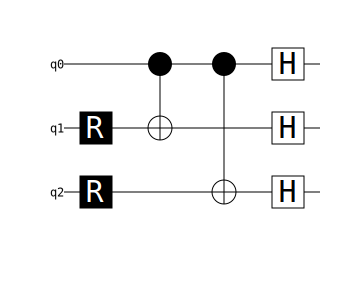

In [71]:
def make_phase_flip_encoding():
    """Encode q0 into the 3-qubit phase flip code."""
    circuit = stim.Circuit()
    circuit.append("R", [1, 2])
    circuit.append("CNOT", [0, 1])
    circuit.append("CNOT", [0, 2])
    circuit.append("H", [0, 1, 2])
    return circuit


circuit = make_phase_flip_encoding()
circuit.diagram("timeline-svg")

### Measuring $X$-type syndromes

For the phase flip code, the syndrome operators are $X_0X_1$ and $X_1X_2$. Measuring an $X$-type parity requires a different ancilla circuit than the $Z$-type case:

- **$Z$-type parity** (bit flip code): CNOT from **data $\to$ ancilla**, followed by measuring the ancilla in the $Z$ basis
- **$X$-type parity** (phase flip code): prepare in the $X$ basis, CNOT from **ancilla $\to$ data**, followed by measuring the ancilla in the $X$ basis

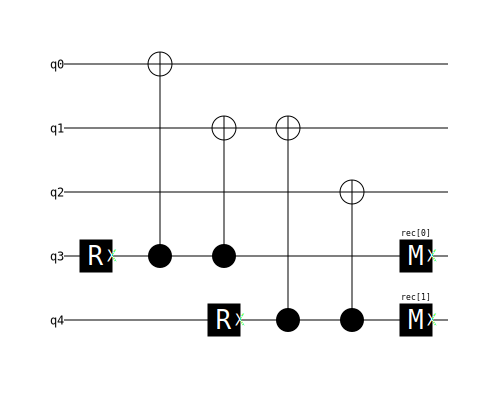

In [ ]:
def make_phase_flip_syndrome():
    """Measure X_0X_1 (into q3) and X_1X_2 (into q4) for the phase flip code."""
    circuit = stim.Circuit()
    # X_0X_1: ancilla q3
    circuit.append("RX", [3])
    circuit.append("CNOT", [3, 0])
    circuit.append("CNOT", [3, 1])
    # X_1X_2: ancilla q4
    circuit.append("RX", [4])
    circuit.append("CNOT", [4, 1])
    circuit.append("CNOT", [4, 2])
    # Measure ancillas
    circuit.append("MX", [3, 4])
    return circuit


circuit = make_phase_flip_syndrome()
circuit.diagram("timeline-svg")

In [72]:
# Verify: Z errors are detected with the same syndrome pattern
for error_qubit in [0, 1, 2]:
    c = stim.Circuit()
    c.append("R", [0])
    c += make_phase_flip_encoding()
    c.append("Z", [error_qubit])
    c += make_phase_flip_syndrome()
    samples = c.compile_sampler().sample(shots=1)
    s1, s2 = int(samples[0, 0]), int(samples[0, 1])
    print(f"Z error on q{error_qubit}: syndrome = ({s1}, {s2})")

Z error on q0: syndrome = (1, 0)
Z error on q1: syndrome = (1, 1)
Z error on q2: syndrome = (0, 1)


The syndrome table is identical to the bit flip code, with $Z$ errors and $Z$ recovery:

| Syndrome $(s_1, s_2)$ | Diagnosis | Recovery |
|:---:|:---|:---|
| (0, 0) | No error | Do nothing |
| (1, 0) | Phase flip on q0 | Apply $Z_0$ |
| (1, 1) | Phase flip on q1 | Apply $Z_1$ |
| (0, 1) | Phase flip on q2 | Apply $Z_2$ |

### Exercise 2.1 — Phase flip code QEC circuit

Build the complete phase flip code QEC circuit: encode $|0_L\rangle \to$ apply `Z_ERROR(p)` on each data qubit $\to$ syndrome extraction $\to$ data measurement. Then decode and compute the logical error rate.

Key differences from the bit flip code:
- **Noise**: use `Z_ERROR` instead of `X_ERROR`
- **Data measurement**: measure in the **$X$ basis** (apply $H$ before $M$), because the codewords live in the $|\pm\rangle$ basis
- **Decoder**: since $Z$ errors flip $X$-basis measurements exactly like $X$ errors flip $Z$-basis measurements, the `decode_bit_flip` function can be **reused directly**

Verify that the logical error rate matches $p_L = 3p^2 - 2p^3$.

In [ ]:
# Exercise 2.1: Phase flip code QEC circuit


def make_phase_flip_qec_circuit(p):
    """Build the complete phase flip code QEC circuit.

    Parameters
    ----------
    p : float
        Physical phase flip error probability per qubit.

    Returns
    -------
    stim.Circuit
        Measurement order: [s1, s2, x0, x1, x2].
    """
    circuit = stim.Circuit()
    circuit.append("R", [0])
    circuit += make_phase_flip_encoding()
    circuit.append("Z_ERROR", [0, 1, 2], p)
    circuit += make_phase_flip_syndrome()
    # TODO: measure data qubits in the X basis
    return circuit


# Test at p = 0.1
p = 0.1
shots = 100000
circuit = make_phase_flip_qec_circuit(p)
samples = circuit.compile_sampler().sample(shots=shots)
logical_errors = decode_bit_flip(samples)  # We can reuse decode_bit_flip!

p_logical = np.mean(logical_errors)
p_theory = 3 * p**2 - 2 * p**3
print(f"Physical error rate:  p = {p}")
print(f"Logical error rate:   p_L = {p_logical:.4f}")
print(f"Theoretical:          3p^2 - 2p^3 = {p_theory:.4f}")

---

## Section 3: The Shor Code

The Shor code concatenates the phase flip code (outer) and the bit flip code (inner) to protect against **both** $X$ and $Z$ errors simultaneously. It uses 9 data qubits organized in three blocks of three:

$$\underbrace{q_0\, q_1\, q_2}_{\text{Block 1}} \quad \underbrace{q_3\, q_4\, q_5}_{\text{Block 2}} \quad \underbrace{q_6\, q_7\, q_8}_{\text{Block 3}}$$

The encoding and syndrome extraction circuits are provided below. Your task is to verify that the code can correct $X$, $Z$, and $Y$ errors on any single qubit.

In [73]:
def make_shor_encoding():
    """Encode q0 into the 9-qubit Shor code (data qubits q0-q8)."""
    circuit = stim.Circuit()
    # Initialize qubits
    circuit.append("R", [1, 2, 3, 4, 5, 6, 7, 8])
    # Phase flip encoding (outer code)
    circuit.append("CNOT", [0, 3])
    circuit.append("CNOT", [0, 6])
    circuit.append("H", [0, 3, 6])
    # Bit flip encoding (inner code, one per block)
    circuit.append("CNOT", [0, 1])
    circuit.append("CNOT", [0, 2])
    circuit.append("CNOT", [3, 4])
    circuit.append("CNOT", [3, 5])
    circuit.append("CNOT", [6, 7])
    circuit.append("CNOT", [6, 8])
    return circuit


def make_shor_syndrome():
    """Syndrome extraction for the Shor code.

    Ancilla qubits:
        q9-q14:  bit flip syndromes (Z-type, 2 per block)
        q15-q16: phase flip syndromes (X-type, between blocks)

    Measurement order: [q9, q10, q11, q12, q13, q14, q15, q16]
    """
    circuit = stim.Circuit()
    # Bit flip syndromes (Z_iZ_j within each block)
    circuit.append("R", [9, 10, 11, 12, 13, 14])
    # Block 1: Z_0Z_1 -> q9, Z_1Z_2 -> q10
    circuit.append("CNOT", [0, 9])
    circuit.append("CNOT", [1, 9])
    circuit.append("CNOT", [1, 10])
    circuit.append("CNOT", [2, 10])
    # Block 2: Z_3Z_4 -> q11, Z_4Z_5 -> q12
    circuit.append("CNOT", [3, 11])
    circuit.append("CNOT", [4, 11])
    circuit.append("CNOT", [4, 12])
    circuit.append("CNOT", [5, 12])
    # Block 3: Z_6Z_7 -> q13, Z_7Z_8 -> q14
    circuit.append("CNOT", [6, 13])
    circuit.append("CNOT", [7, 13])
    circuit.append("CNOT", [7, 14])
    circuit.append("CNOT", [8, 14])
    # Measure ancillas in the Z basis
    circuit.append("M", [9, 10, 11, 12, 13, 14])

    # Phase flip syndromes (X-type, between blocks)
    circuit.append("RX", [15, 16])
    # X_0X_1X_2 X_3X_4X_5 -> q15
    for q in [0, 1, 2, 3, 4, 5]:
        circuit.append("CNOT", [15, q])
    # X_3X_4X_5 X_6X_7X_8 -> q16
    for q in [3, 4, 5, 6, 7, 8]:
        circuit.append("CNOT", [16, q])
    # Measure ancillas in the X basis
    circuit.append("MX", [15, 16])
    return circuit

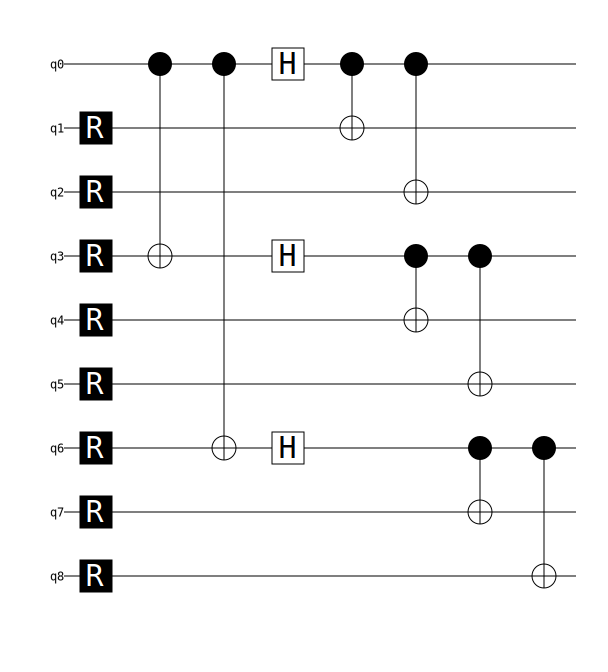

In [74]:
make_shor_encoding().diagram("timeline-svg")

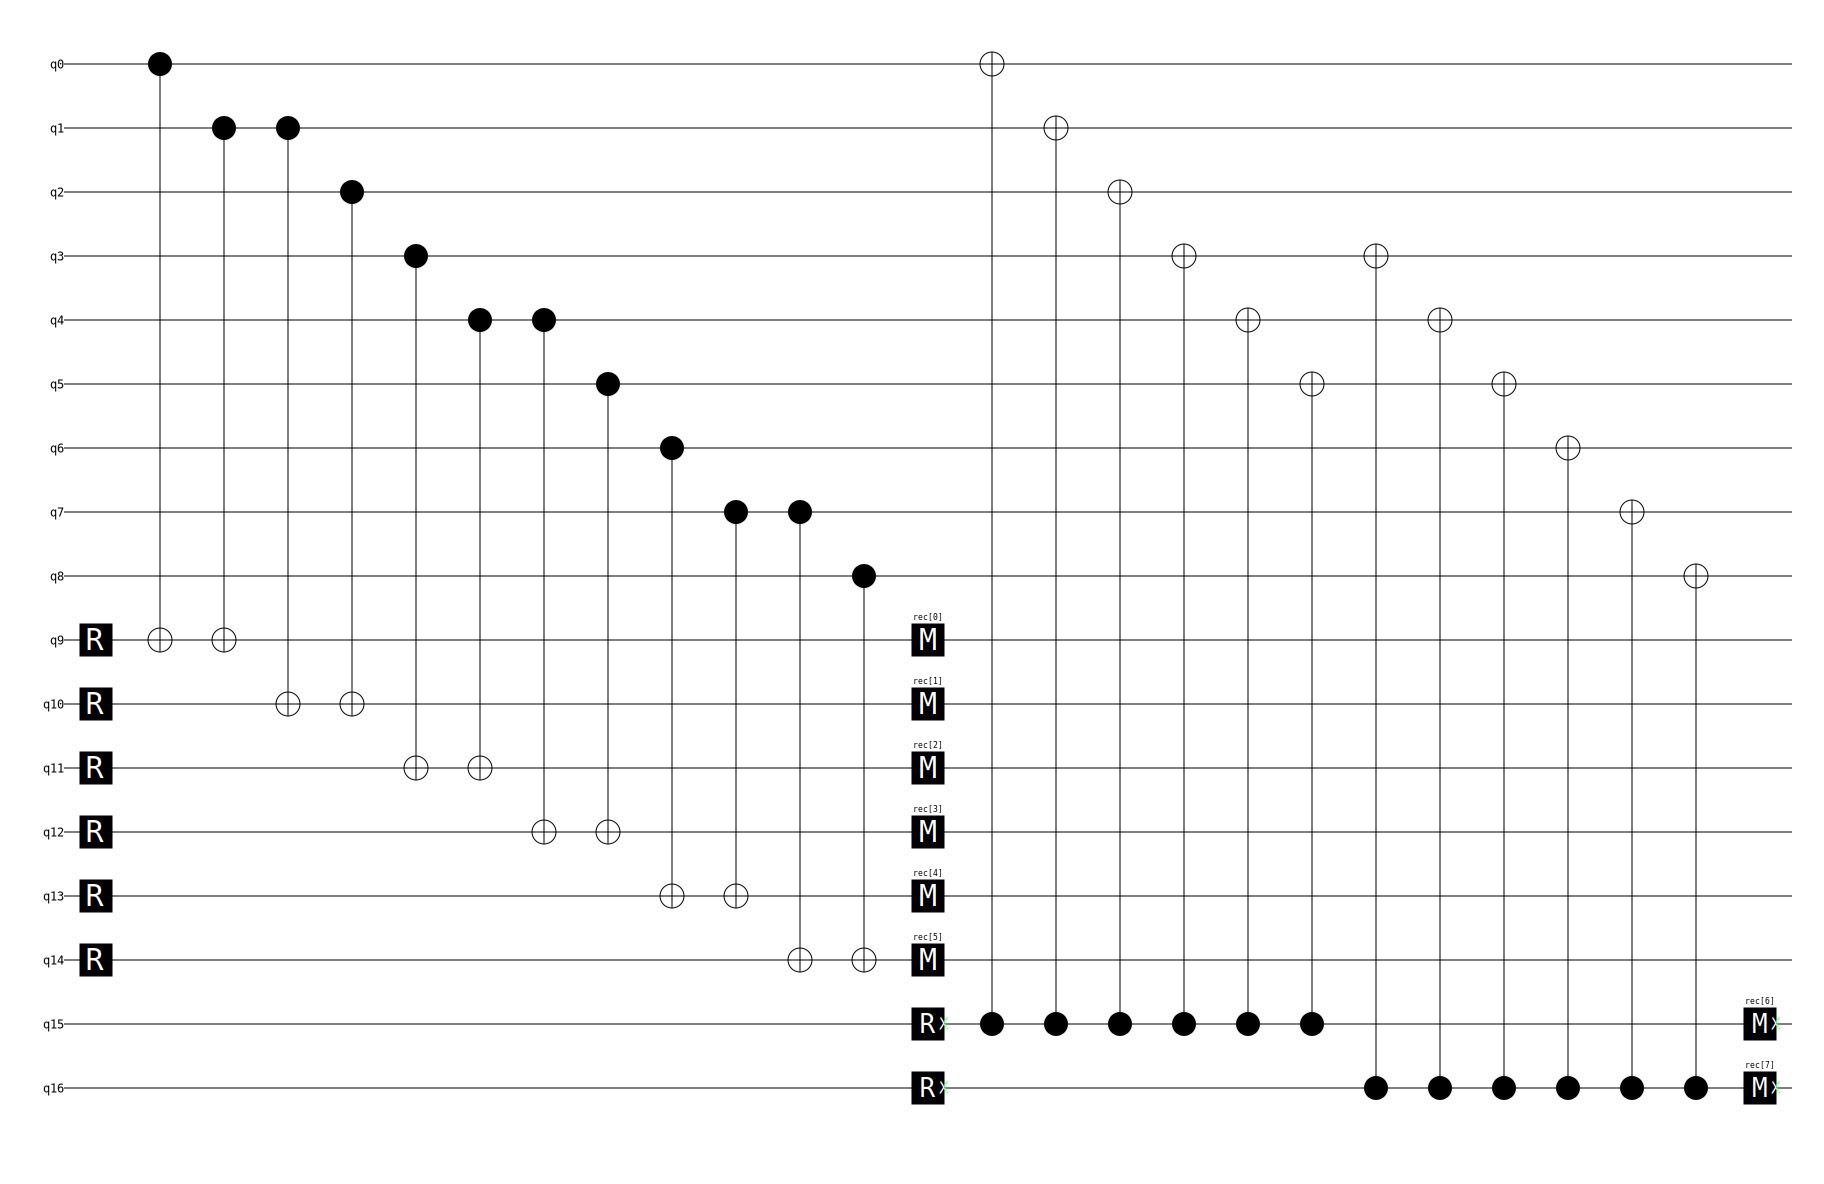

In [75]:
make_shor_syndrome().diagram("timeline-svg")

In [ ]:
# Shor code syndrome table
for error_name in ["X", "Z", "Y"]:
    print(f"--- {error_name} errors ---")
    for q in range(9):
        c = stim.Circuit()
        c.append("R", [0])
        c += make_shor_encoding()
        c.append(error_name, [q])
        c += make_shor_syndrome()
        samples = c.compile_sampler().sample(shots=1)
        syndrome = tuple(int(b) for b in samples[0])
        print(f"  {error_name} on q{q}: syndrome = {syndrome}")
    print()

--- X errors ---
  X on q0: syndrome = (1, 0, 0, 0, 0, 0, 0, 0)
  X on q1: syndrome = (1, 1, 0, 0, 0, 0, 0, 0)
  X on q2: syndrome = (0, 1, 0, 0, 0, 0, 0, 0)
  X on q3: syndrome = (0, 0, 1, 0, 0, 0, 0, 0)
  X on q4: syndrome = (0, 0, 1, 1, 0, 0, 0, 0)
  X on q5: syndrome = (0, 0, 0, 1, 0, 0, 0, 0)
  X on q6: syndrome = (0, 0, 0, 0, 1, 0, 0, 0)
  X on q7: syndrome = (0, 0, 0, 0, 1, 1, 0, 0)
  X on q8: syndrome = (0, 0, 0, 0, 0, 1, 0, 0)

--- Z errors ---
  Z on q0: syndrome = (0, 0, 0, 0, 0, 0, 1, 0)
  Z on q1: syndrome = (0, 0, 0, 0, 0, 0, 1, 0)
  Z on q2: syndrome = (0, 0, 0, 0, 0, 0, 1, 0)
  Z on q3: syndrome = (0, 0, 0, 0, 0, 0, 1, 1)
  Z on q4: syndrome = (0, 0, 0, 0, 0, 0, 1, 1)
  Z on q5: syndrome = (0, 0, 0, 0, 0, 0, 1, 1)
  Z on q6: syndrome = (0, 0, 0, 0, 0, 0, 0, 1)
  Z on q7: syndrome = (0, 0, 0, 0, 0, 0, 0, 1)
  Z on q8: syndrome = (0, 0, 0, 0, 0, 0, 0, 1)

--- Y errors ---
  Y on q0: syndrome = (1, 0, 0, 0, 0, 0, 1, 0)
  Y on q1: syndrome = (1, 1, 0, 0, 0, 0, 1, 0)
  Y on 

---

## Section 4: Preview — stim Detectors

So far, we have been extracting syndromes by sampling all measurements and decoding in Python. stim provides a more powerful abstraction: **detectors** and **observables**.

- A `DETECTOR` is a set of measurement records whose combined parity should be 0 in the absence of errors. When an error flips the parity, the detector "fires" (reports 1 instead of 0).
- An `OBSERVABLE_INCLUDE` marks which measurements contribute to the logical observable of interest.

With these annotations, `compile_detector_sampler()` directly outputs **detection events** (which syndromes fired) and **observable flips** (whether a logical error occurred), without manual decoding.

In [80]:
# Bit flip code with DETECTOR and OBSERVABLE_INCLUDE annotations
p = 0.1

circuit = stim.Circuit()
circuit.append("R", 0)
# Encode
circuit += make_bit_flip_encoding()
# Noise
circuit.append("X_ERROR", [0, 1, 2], p)
# Syndrome extraction
circuit += make_bit_flip_syndrome()
# Detectors: syndrome measurements should be 0 without errors
circuit.append("DETECTOR", [stim.target_rec(-2)])  # Z_0 Z_1
circuit.append("DETECTOR", [stim.target_rec(-1)])  # Z_1 Z_2
# Data qubit measurement
circuit.append("M", [0, 1, 2])
# Observable: logical Z = Z_0 (q0 measurement)
circuit.append("OBSERVABLE_INCLUDE", [stim.target_rec(-3)], 0)

print("Circuit with detectors:")
print(circuit)

Circuit with detectors:
R 0 1 2
CX 0 1 0 2
X_ERROR(0.1) 0 1 2
R 3 4
CX 0 3 1 3 1 4 2 4
M 3 4
DETECTOR rec[-2]
DETECTOR rec[-1]
M 0 1 2
OBSERVABLE_INCLUDE(0) rec[-3]


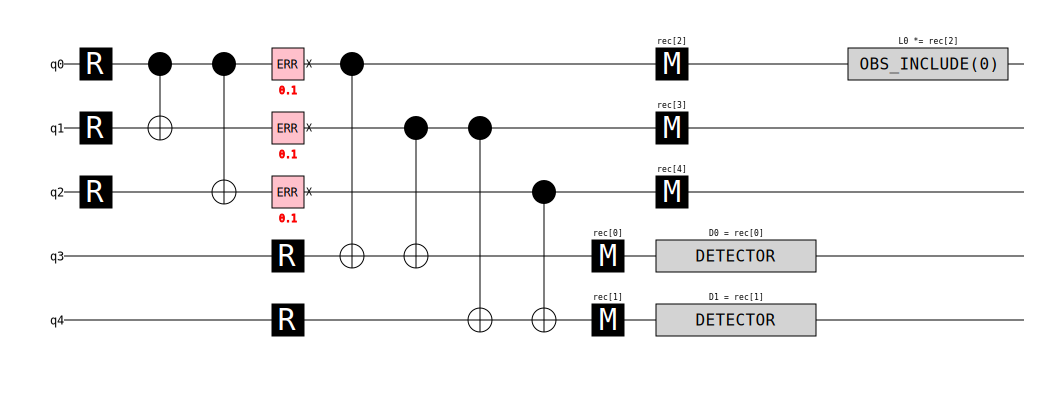

In [81]:
circuit.diagram("timeline-svg")

In [92]:
# Sample detection events and observable flips
shots = 100
detector_sampler = circuit.compile_detector_sampler()
det_samples, obs_samples = detector_sampler.sample(
    shots=shots, separate_observables=True
)

In [93]:
det_samples

array([[False, False],
       [False, False],
       [False, False],
       [ True, False],
       [False, False],
       [False, False],
       [ True,  True],
       [False,  True],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False,  True],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [ True, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [ True, False],
       [ True, False],
       [False, False],
       [False,  True],
       [ True,  True],
       [False, False],
       [False, False],
       [False, False],
       [ True, False],
       [False, False],
       [False, False],
       [False, False],
       [Fal

In [94]:
obs_samples

array([[False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [

In [95]:
print(f"Detector 0 (Z_0Z_1) fire rate: {np.mean(det_samples[:, 0]):.4f}")
print(f"Detector 1 (Z_1Z_2) fire rate: {np.mean(det_samples[:, 1]):.4f}")
print(f"Logical error rate (before correction): {np.mean(obs_samples[:, 0]):.4f}")

Detector 0 (Z_0Z_1) fire rate: 0.1300
Detector 1 (Z_1Z_2) fire rate: 0.1300
Logical error rate (before correction): 0.0900
